# Life Expectancy Prediction Project
Machine Learning Regression Project

Algorithms used:
- Linear Regression
- Random Forest Regressor
- Support Vector Regression (SVR)

Generated on: 2026-03-13

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

## 2. Load Dataset

In [2]:
df = pd.read_csv('Life-Expectancy-Data-Averaged.csv')
df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status,Life_expectancy
0,Afghanistan,Asia,2007.5,71.08125,98.61250,265.804969,0.016125,64.5625,24.3750,22.46250,55.3750,55.1250,0.022500,408.5625,27.450625,16.58125,15.58125,2.90000,1.0,59.65625
1,Albania,Rest of Europe,2007.5,15.25625,17.14375,83.132969,4.696875,98.0000,95.9375,25.85625,98.1250,98.0625,0.025625,3071.1250,2.969375,1.61875,1.70000,9.24375,1.0,75.95000
2,Algeria,Africa,2007.5,26.75625,31.19375,113.439281,0.400625,88.3125,93.2500,24.86875,91.7500,91.8750,0.021875,3745.1250,34.820625,6.09375,5.97500,6.99375,1.0,73.78750
3,Angola,Africa,2007.5,88.76875,144.16250,297.844063,4.935625,68.8125,64.0000,22.51875,35.7500,55.5625,1.303750,2647.8125,21.623750,6.19375,6.66875,4.60625,1.0,52.82500
4,Antigua and Barbuda,Central America and Caribbean,2007.5,9.47500,11.51875,142.478813,7.755000,98.2500,75.4375,25.85000,96.9375,98.3125,0.125000,14678.7500,0.085000,3.42500,3.37500,9.01875,1.0,75.35000


## 3. Basic Data Exploration

In [3]:
df.shape

(179, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      179 non-null    object 
 1   Region                       179 non-null    object 
 2   Year                         179 non-null    float64
 3   Infant_deaths                179 non-null    float64
 4   Under_five_deaths            179 non-null    float64
 5   Adult_mortality              179 non-null    float64
 6   Alcohol_consumption          179 non-null    float64
 7   Hepatitis_B                  179 non-null    float64
 8   Measles                      179 non-null    float64
 9   BMI                          179 non-null    float64
 10  Polio                        179 non-null    float64
 11  Diphtheria                   179 non-null    float64
 12  Incidents_HIV                179 non-null    float64
 13  GDP_per_capita      

In [5]:
df.describe()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status,Life_expectancy
count,179.0,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000
mean,2007.5,30.363792,42.938268,192.251775,4.820882,84.292598,77.344972,25.032926,86.499651,86.271648,0.894288,11540.924930,36.675915,4.865852,4.899825,7.632123,0.793296,68.856075
std,0.0,26.725485,42.916952,111.659044,3.914554,13.820223,17.315208,2.165490,13.581153,13.931532,2.311895,16893.054182,136.655286,4.111094,4.195663,3.126912,0.406077,9.197699
min,2007.5,2.381250,3.000000,57.710313,0.000025,30.687500,16.250000,20.212500,35.750000,31.312500,0.010000,263.937500,0.085000,0.100000,0.100000,1.337500,0.000000,45.606250
25%,2007.5,8.159375,9.775000,107.046906,1.317813,78.218750,64.000000,23.225000,80.531250,80.812500,0.080000,1409.906250,2.108125,1.756250,1.731250,4.946875,1.000000,62.303125
50%,2007.5,19.368750,23.137500,164.432406,4.209375,88.000000,83.000000,25.650000,92.375000,92.062500,0.164375,4402.625000,7.660625,3.556250,3.718750,7.831250,1.000000,71.506250
75%,2007.5,48.959375,68.321875,247.523922,7.843438,94.375000,92.250000,26.425000,96.062500,95.781250,0.516250,12037.781250,22.745313,7.165625,7.056250,10.365625,1.000000,74.937500
max,2007.5,115.718750,178.725000,572.974312,15.100000,98.875000,99.000000,31.687500,98.937500,99.000000,18.164375,102972.687500,1321.239375,27.100000,27.943750,13.268750,1.000000,82.456250


## 4. Check Missing Values

In [6]:
df.isnull().sum()

Country                        0
Region                         0
Year                           0
Infant_deaths                  0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Population_mln                 0
Thinness_ten_nineteen_years    0
Thinness_five_nine_years       0
Schooling                      0
Economy_status                 0
Life_expectancy                0
dtype: int64

## 5. Handle Missing Values

In [7]:
df = df.fillna(df.mean(numeric_only=True))

## 6. Encode Categorical Features

In [8]:
le = LabelEncoder()

df['Country'] = le.fit_transform(df['Country'])
df['Region'] = le.fit_transform(df['Region'])
df['Economy_status'] = le.fit_transform(df['Economy_status'])

## 7. Correlation Heatmap

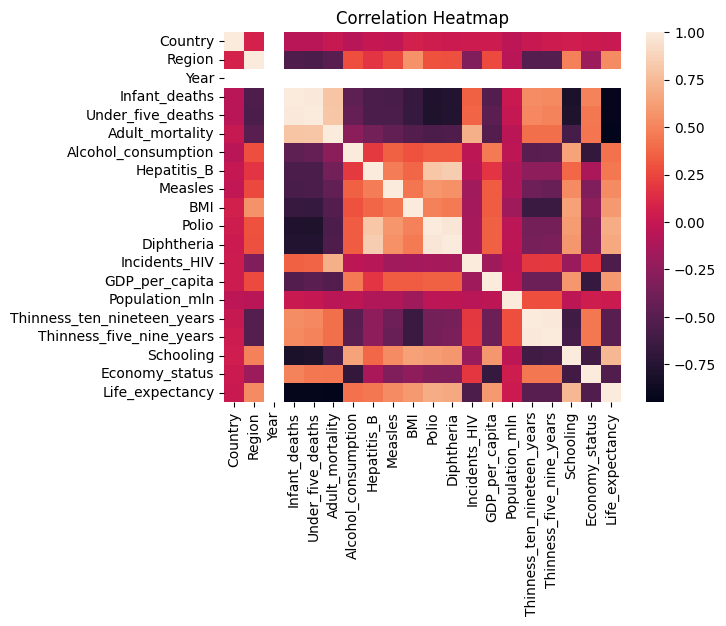

In [9]:
plt.figure()
sns.heatmap(df.corr())
plt.title('Correlation Heatmap')
plt.show()

## 8. Distribution of Life Expectancy

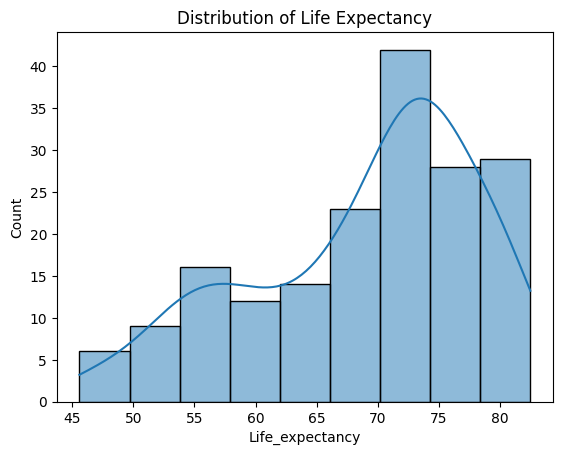

In [10]:
plt.figure()
sns.histplot(df['Life_expectancy'], kde=True)
plt.title('Distribution of Life Expectancy')
plt.show()

## 9. Define Features and Target

In [11]:
X = df.drop('Life_expectancy', axis=1)
y = df['Life_expectancy']

## 10. Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 11. Feature Scaling

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 12. Linear Regression Model

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print('Linear Regression MSE:', mse_lr)
print('Linear Regression R2:', r2_lr)

Linear Regression MSE: 1.1132936268097877
Linear Regression R2: 0.9876010363041621


## 13. Random Forest Model

In [15]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('Random Forest MSE:', mse_rf)
print('Random Forest R2:', r2_rf)

Random Forest MSE: 2.2150286931423633
Random Forest R2: 0.9753308025033688


## 14. Support Vector Regression

In [16]:
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print('SVR MSE:', mse_svr)
print('SVR R2:', r2_svr)

SVR MSE: 12.93877214375809
SVR R2: 0.8558984240852164


## 15. Model Comparison

In [17]:
results = pd.DataFrame({
    'Model': ['Linear Regression','Random Forest','SVR'],
    'MSE': [mse_lr, mse_rf, mse_svr],
    'R2 Score': [r2_lr, r2_rf, r2_svr]
})

results

,Model,MSE,R2 Score
0,Linear Regression,1.113294,0.987601
1,Random Forest,2.215029,0.975331
2,SVR,12.938772,0.855898


## 16. R2 Score Comparison Graph

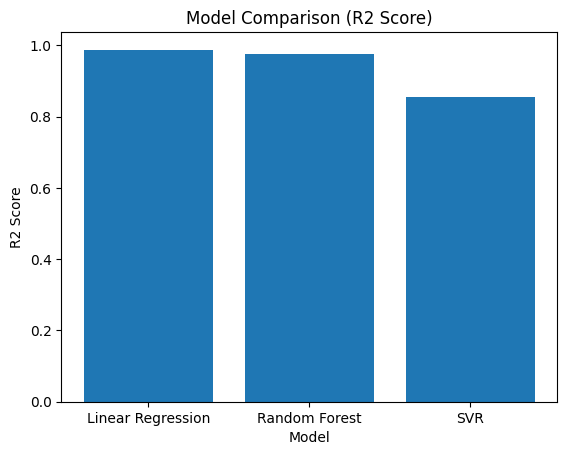

In [18]:
plt.figure()
plt.bar(results['Model'], results['R2 Score'])
plt.title('Model Comparison (R2 Score)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.show()

## 17. MSE Comparison Graph

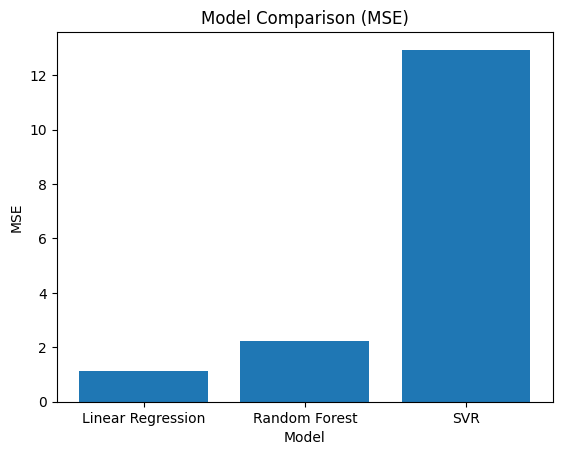

In [19]:
plt.figure()
plt.bar(results['Model'], results['MSE'])
plt.title('Model Comparison (MSE)')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.show()

## 18. Actual vs Predicted (Random Forest)

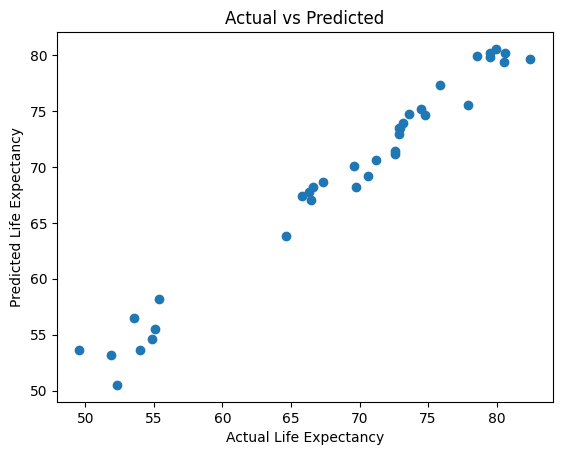

In [20]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Actual vs Predicted')
plt.show()

## 19. Residual Plot

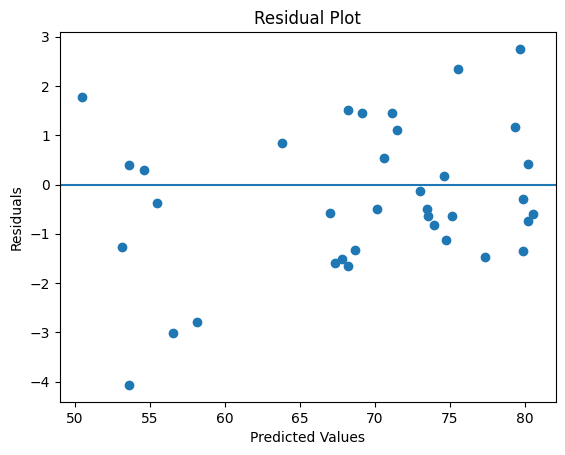

In [21]:
residuals = y_test - y_pred_rf

plt.figure()
plt.scatter(y_pred_rf, residuals)
plt.axhline(0)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()